# 🧪 实战练手: 双重差分 (DID) 政策评估

> **目标**: 0-1 手写 DID 代码，评估某城市 "发放消费券" 对 "销售额" 的因果效应。
> **SOP**: 业务定义 -> 平行趋势检验 -> 模型回归 -> 稳健性检验。

## 📖 核心概念 (SQL 类比)
*   **Difference (1)**: 干预后 - 干预前 (时间维度的差异)。 `Sales_Post - Sales_Pre`
*   **Difference (2)**: 干预组 - 对照组 (空间维度的差异)。 `Group_Treated - Group_Control`
*   **DID**: 两次差分剩下的就是 **Net Impact**。

---

In [ ]:
# 0. 函数加油站 (Function Cheat Sheet)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# -------------------------------------------------------
# 1. smf.ols(formula, data).fit()
#    语法: 'y ~ x1 + x2 + x1:x2'
#    解释: 最小二乘法回归，x1:x2 代表交互项
# -------------------------------------------------------
# 2. sns.lineplot(..., err_style='bars')
#    解释: 画折线图并显示置信区间，用于检查平行趋势
# -------------------------------------------------------

## 1. 数据准备 (Data Prep)
为了确保我们有 "上帝视角" (知道真实的 Treatment Effect 是多少)，这里我们模拟生成一组面板数据。
*   **Scenario**: City A (Treated) 在 Week 5 发放了消费券; City B (Control) 没发。
*   **True Effect**: +100 元。

In [ ]:
# 🏭 数据生成器 (无需修改，运行即可)
def generate_did_data(n_weeks=10, n_samples=500):
    np.random.seed(42)
    
    # 时间与分组
    time = np.repeat(range(n_weeks), n_samples)
    city = np.tile(np.random.choice([0, 1], n_samples), n_weeks) # 0=Control, 1=Treat
    
    df = pd.DataFrame({'time': time, 'city': city})
    
    # 基础销量 (Base Sales)
    df['sales'] = 500 + (df['time'] * 10) + (df['city'] * 50) + np.random.normal(0, 50, len(df))
    
    # 施加干预 (Treatment Effect)
    # 设定: City 1 在 Time >= 5 时，销量增加 100
    df['post'] = (df['time'] >= 5).astype(int)
    df['treat_effect'] = 100 * df['city'] * df['post']
    df['sales'] += df['treat_effect']
    
    return df

df = generate_did_data()
df.head()

In [14]:
df.head()

,time,city,sales,post,treat_effect
0,0,0,457.660314,0,0
1,0,1,474.257639,0,0
2,0,0,477.674252,0,0
3,0,0,542.819940,0,0
4,0,0,510.704687,0,0


<Axes: xlabel='sales', ylabel='Count'>

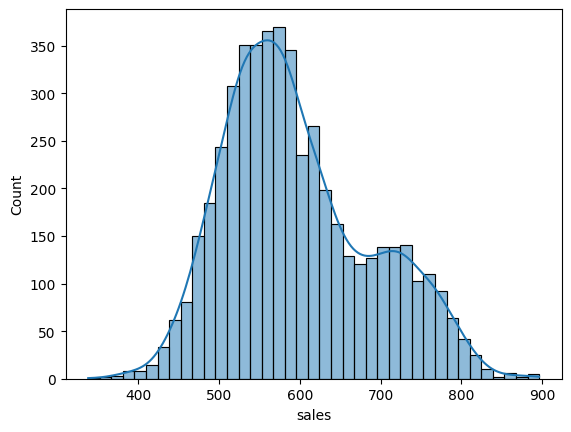

In [22]:
sns.histplot(df['sales'], kde=True)

## 2. 挑战 Level 1: 可视化平行趋势 (Assumption Check)
**任务**: 使用 `sns.lineplot` 画出两组 (hue='city') 随时间 (x='time') 变化的销量趋势。
*   **观察**: 在 time < 5 之前，两条线是平行的吗？

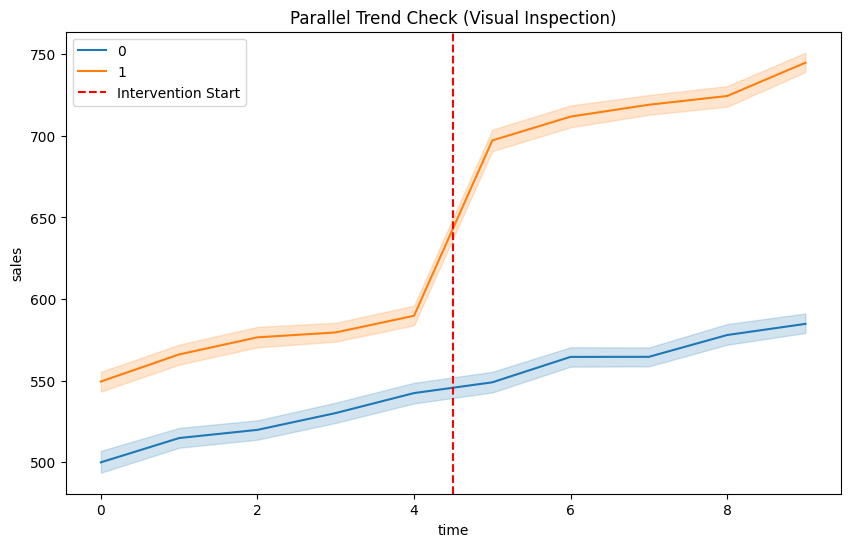


=== Parallel Trend Slope Check (Should be similar) ===


,City,Slope (Trend),P-value,R-squared
0,Control,10.018715,1.297238e-22,0.075639
1,Treated,9.407178,2.239478e-21,0.068114


In [16]:
# 1. 可视化 (Visualization)
# 自动定位干预线 (Dynamic Intervention line)
pre_max = df[df['time'] < 5]['time'].max()
post_min = df[df['time'] >= 5]['time'].min()
intervention_x = (pre_max + post_min) / 2

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='time', y='sales', hue='city')
plt.axvline(x=intervention_x, color='red', linestyle='--', label='Intervention Start')
plt.title('Parallel Trend Check (Visual Inspection)')
plt.legend()
plt.show()

# 2. 科学检验: 斜率一致性 (Slope Consistency Check)
# 只取干预前的数据 (Pre-intervention)
df_pre = df[df['time'] < 5]

# 分别计算两组的回归斜率 (Slope)
slopes = []
for city in [0, 1]:
    # 简单回归: sales = intercept + slope * time
    sub_df = df_pre[df_pre['city'] == city]
    model_pre = smf.ols("sales ~ time", data=sub_df).fit()
    
    slopes.append({
        'City': 'Control' if city==0 else 'Treated',
        'Slope (Trend)': model_pre.params['time'],
        'P-value': model_pre.pvalues['time'],
        'R-squared': model_pre.rsquared
    })

# 输出 DataFrame 供对比
df_slope_check = pd.DataFrame(slopes)
print("\n=== Parallel Trend Slope Check (Should be similar) ===")
df_slope_check

## 3. 挑战 Level 2: 统计模型回归 (Execution)
**任务**: 使用 `smf.ols` 跑回归模型，量化 DID 效应。
*   **公式**: `sales ~ city * post`
*   **目标**: 提取交互项 `city:post` 的系数，看它是否接近真实值 (100)。

In [17]:
model = smf.ols("sales ~ city * post",data = df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     3487.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:57:05   Log-Likelihood:                -26821.
No. Observations:                5000   AIC:                         5.365e+04
Df Residuals:                    4996   BIC:                         5.368e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    521.3908      1.480    352.186      0.0

## 4. 挑战 Level 3: 稳健性检验 (Placebo Test)
**任务**: 验证结果不是瞎猫碰死耗子。
*   **方法**: 假装政策提前了 (比如 Time=3 就开始干预了)。
*   **预期**: 在虚假的时间点 (Time 3-4)，交互项应该 **不显著** (系数接近0)。

In [ ]:
# [YOUR CODE HERE]
# 1. 创建假的 fake_post (e.g. time >= 3)
# 2. 只选取真实干预前的数据 (time < 5) 进行测试，以避免真实效应的干扰
# 3. 跑回归: sales ~ city * fake_post


In [20]:
# 1. 创建假的 fake_post (假装 Time >= 3 就开始促销了)
# 注意：我们要只取真实干预前的数据 (Time < 5) 来做这个测试，
# 因为 Time >= 5 之后的数据已经受真实促销影响了，会干扰测试。
df_pre = df[df['time'] < 5].copy() 
df_pre['fake_post'] = (df_pre['time'] >= 3).astype(int)

# 2. 跑回归: 这里的 Y 依然是真实的 sales
# 我们看的是：在没有促销的这段时间里，fake_post 是否"显得"有效？
model_placebo = smf.ols("sales ~ city * fake_post", data=df_pre).fit()
print(model_placebo.summary()) 


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     256.1
Date:                Tue, 17 Feb 2026   Prob (F-statistic):          6.84e-145
Time:                        13:10:38   Log-Likelihood:                -13328.
No. Observations:                2500   AIC:                         2.666e+04
Df Residuals:                    2496   BIC:                         2.669e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        511.5011      1.850    276.

## 5. 参考答案 (Reference)
> *尝试自己写完后再看！*

In [ ]:
# Level 1
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='time', y='sales', hue='city')
plt.axvline(x=4.5, color='red', linestyle='--')
plt.title('Parallel Trend Check')
plt.show()

# Level 2
# city*post 会自动展开为: city + post + city:post
model = smf.ols("sales ~ city * post", data=df).fit()
print(model.summary())

# Level 3 (Placebo)
df_pre = df[df['time'] < 5].copy() # 只看前5周
df_pre['fake_post'] = (df_pre['time'] >= 3).astype(int) # 假装第3周开始
model_placebo = smf.ols("sales ~ city * fake_post", data=df_pre).fit()
print("Placebo Test Coefficient:", model_placebo.params['city:fake_post'])
# P值应该很大 (>0.05)，系数应该很小